In [8]:
%load_ext autoreload
%autoreload 2
from scripts.utils import *
from scripts.gaussianclassifiers import *
from scripts.dcf import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Analisi e Valutazione dei Modelli MVG per Diverse Applicazioni Target

L'obiettivo di questa fase di progetto consiste nell'analizzare e confrontare le prestazioni del classificatore basato su Modelli di Mistura Gaussiana (MVG) e delle sue varianti, come i modelli Tied e Naive Bayes. La valutazione non si limiterà al semplice conteggio degli errori assoluti, ma terrà in considerazione l'impatto economico o operativo delle decisioni prese. A tal fine, le prestazioni verranno misurate quantificando il costo atteso di Bayes rispetto a diversi scenari applicativi, ognuno caratterizzato da una specifica probabilità a priori delle classi e da differenti pesi assegnati agli errori.

## Parametrizzazione dell'Applicazione e Soglie Decisionali

In un problema di classificazione binaria, ogni applicazione target viene definita in modo univoco da una terna di parametri indicata con $(\pi_{1}, C_{fn}, C_{fp})$. Il termine $\pi_{1}$ rappresenta la probabilità a priori che un campione appartenga alla classe positiva, ovvero l'incidenza attesa dei casi genuini nella popolazione di test. I parametri $C_{fn}$ e $C_{fp}$ quantificano rispettivamente il costo operativo associato a un errore di falso negativo (rifiutare un target legittimo) e a un errore di falso positivo (accettare un'istanza falsa). Per prendere decisioni ottimali in grado di minimizzare il rischio di Bayes, il sistema confronta i log-likelihood ratio generati dal modello probabilistico con una soglia teorica ottimale $t$. Tale soglia dipende direttamente dall'applicazione ed è definita analiticamente dall'equazione:

$$t=-\log\frac{\pi_{1}C_{fn}}{(1-\pi_{1})C_{fp}}$$

Modificando i pesi all'interno dell'applicazione, il comportamento del sistema cambia drasticamente: ad esempio, un incremento del costo dei falsi positivi $C_{fp}$ sposterà la soglia, inducendo il riconoscitore a essere più conservativo per garantire requisiti di sicurezza più stringenti.

## Rappresentazione tramite Prior Effettivo

Per semplificare il confronto analitico tra i diversi sistemi e ricondurre scenari fortemente eterogenei a una singola metrica unificata, i costi di mis-classificazione possono essere matematicamente inglobati all'interno delle probabilità a priori. Una qualsiasi applicazione definita dalla terna $(\pi_{1}, C_{fn}, C_{fp})$ risulta operativamente equivalente a un'applicazione normalizzata in cui i costi sono assunti unitari, formalmente definita come $(\tilde{\pi}, 1, 1)$. Il termine $\tilde{\pi}$ prende il nome di prior effettivo. L'introduzione di questa grandezza permette di osservare direttamente come l'imposizione di una maggiore sicurezza, traducibile in un costo più elevato per l'accettazione di elementi spuri, equivalga concettualmente a ipotizzare una probabilità a priori intrinsecamente più bassa per la classe dei soggetti legittimi. Dal punto di vista computazionale, il prior effettivo può essere ricavato a partire dalla log-odds $\tilde{p}$ tramite la trasformazione logistica:

$$\tilde{\pi}=\frac{1}{1+e^{-\tilde{p}}}$$

dove il parametro $\tilde{p}$ coincide funzionalmente con l'opposto della soglia teorica ottimale calcolata per la specifica applicazione considerata.

## Rischio Empirico e Limiti di Riconoscimento

La valutazione quantitativa del potere discriminante dei modelli si basa sull'estrazione della Detection Cost Function normalizzata (DCF), la quale esprime il rischio empirico effettivamente assunto dal classificatore operando sui dati di valutazione. Tuttavia, la validità della DCF reale dipende dalla corretta calibrazione degli score; spesso, infatti, i parametri del modello si rivelano non perfettamente allineati alla popolazione di test, rendendo la soglia teorica sub-ottimale. Per isolare l'efficacia intrinseca del modello dagli errori di calibrazione, l'analisi richiede il calcolo del Minimum DCF. Questa metrica definisce il limite inferiore teorico del costo, che il classificatore potrebbe raggiungere se si operasse una selezione oracolare della miglior soglia decisionale direttamente sui dati. L'eventuale divario (gap) tra la DCF effettiva e il Minimum DCF quantifica numericamente la perdita di prestazioni imputabile esclusivamente alla mis-calibrazione del riconoscitore.

## Analisi Globale tramite Bayes Error Plots

Al fine di ottenere un prospetto completo del comportamento dei riconoscitori in condizioni di estrema incertezza applicativa, si sfrutta la rappresentazione grafica dei Bayes Error Plots. In questo spazio analitico, le funzioni di costo normalizzate (sia la DCF reale che quella minima) vengono tracciate in funzione dei prior log-odds $\tilde{p}$, estendendo l'analisi su un dominio continuo che abbraccia un'ampia varietà di scenari possibili. Confrontare le curve tracciate dai diversi classificatori gaussiani permette di stabilire in modo visivo non solo quali architetture offrano il miglior potenziale di separazione delle classi, ma soprattutto quali varianti garantiscano la calibrazione più coerente e stabile al variare delle condizioni operative esterne.

In [4]:
D,L,labels=init_dataset()


Facciamo le previsioni attraverso l'MVG Classifier

In [5]:
(DTR, LTR), (DVAL, LVAL)=split_db_2to1(D,L)
predictions=MVG_Classifier(DTR,LTR,DVAL,LVAL)
predictions

The error rate for Binary Classifier based on MVG is: 6.999999999999995% and the accuracy: 93.0%


array([0, 0, 1, ..., 0, 0, 0], shape=(2000,))

In [9]:
M=get_confusion_mat(predictions,LVAL)
M

array([[927.,  75.],
       [ 65., 933.]])

In [10]:
# 5 applicazioni con parametri diversi (π1, Cfn, Cfp)
applications = [
    (0.5, 1.0, 1.0),   # prior uniforme e costi uniformi
    (0.9, 1.0, 1.0),   # prior più alto per campioni genuini
    (0.1, 1.0, 1.0),   # prior più alto per campioni falsi
    (0.5, 1.0, 9.0),   # prior uniforme, costo alto per falsi positivi (focalizzato sulla sicurezza)
    (0.5, 9.0, 1.0)    # prior uniforme, costo alto per falsi negativi (focalizzato sulla facilità d'uso)
]

dcf_results = []
for prior, cfn, cfp in applications:
    # Calcolo del prior effettivo
    eff_prior = (prior * cfn) / (prior * cfn + (1 - prior) * cfp)
    dcf_u_value=DCF_u(predictions,LVAL,prior,cfn,cfp)
    dcf_norm_value = DCF_norm(predictions, LVAL, prior, cfn, cfp)
    dcf_results.append(dcf_norm_value)
    print(f"Applicazione (π1={prior}, Cfn={cfn}, Cfp={cfp}) -> π effettivo = {eff_prior:.1f}")
    print(f"  DCF_u = {dcf_u_value:.4f} || DCF_norm = {dcf_norm_value:.4f}\n")



Applicazione (π1=0.5, Cfn=1.0, Cfp=1.0) -> π effettivo = 0.5
  DCF_u = 0.0700 || DCF_norm = 0.1399

Applicazione (π1=0.9, Cfn=1.0, Cfp=1.0) -> π effettivo = 0.9
  DCF_u = 0.0735 || DCF_norm = 0.7352

Applicazione (π1=0.1, Cfn=1.0, Cfp=1.0) -> π effettivo = 0.1
  DCF_u = 0.0664 || DCF_norm = 0.6641

Applicazione (π1=0.5, Cfn=1.0, Cfp=9.0) -> π effettivo = 0.1
  DCF_u = 0.3321 || DCF_norm = 0.6641

Applicazione (π1=0.5, Cfn=9.0, Cfp=1.0) -> π effettivo = 0.9
  DCF_u = 0.3676 || DCF_norm = 0.7352



Calcoliamo ora i vari llr in modo da darli in pasto alle funzioni di decisione Bayesiana

In [11]:
#Calcoliamo tutti gli llr
S_MVG=getS(DVAL,get_params_MVG(DTR,LTR))
S_TiedC=getS_Tied_Covariance(DVAL,get_params_Tied_Covariance(DTR,LTR))
S_Naive=getS(DVAL,get_params_Naive_Bayes(DTR,LTR))

llr_MVG=S_MVG[1]-S_MVG[0]
llr_TiedC=S_TiedC[1]-S_TiedC[0]
llr_Naive=S_Naive[1]-S_Naive[0]

models={
    "MVG Classifier":llr_MVG,
    "Tied Covariance Classifier":llr_TiedC,
    "Naive Bayes Classifier":llr_Naive,
}

effective_priors = [0.1, 0.5, 0.9]

for model_name,model_llr in models.items():
    print(f"--- Valutazione Modello: {model_name} ---")

    for pi_eff in effective_priors:
        predictions=get_bayes_decision(model_llr,pi_eff,1,1)
        actual_dcf=DCF_norm(predictions,LVAL,pi_eff,1,1)
        min_dcf=compute_min_dcf(model_llr,LVAL,pi_eff,1,1)

        print(f"Applicazione (π~ = {pi_eff:.1f}, Cfn=1, Cfp=1):")
        print(f"  Actual DCF:  {actual_dcf:.4f}")
        print(f"  Minimum DCF: {min_dcf:.4f}")

--- Valutazione Modello: MVG Classifier ---
Applicazione (π~ = 0.1, Cfn=1, Cfp=1):
  Actual DCF:  0.3051
  Minimum DCF: 0.2629
Applicazione (π~ = 0.5, Cfn=1, Cfp=1):
  Actual DCF:  0.1399
  Minimum DCF: 0.1302
Applicazione (π~ = 0.9, Cfn=1, Cfp=1):
  Actual DCF:  0.4001
  Minimum DCF: 0.3423
--- Valutazione Modello: Tied Covariance Classifier ---
Applicazione (π~ = 0.1, Cfn=1, Cfp=1):
  Actual DCF:  1.0000
  Minimum DCF: 0.8455
Applicazione (π~ = 0.5, Cfn=1, Cfp=1):
  Actual DCF:  0.1860
  Minimum DCF: 0.1850
Applicazione (π~ = 0.9, Cfn=1, Cfp=1):
  Actual DCF:  1.0000
  Minimum DCF: 0.5789
--- Valutazione Modello: Naive Bayes Classifier ---
Applicazione (π~ = 0.1, Cfn=1, Cfp=1):
  Actual DCF:  0.3022
  Minimum DCF: 0.2570
Applicazione (π~ = 0.5, Cfn=1, Cfp=1):
  Actual DCF:  0.1439
  Minimum DCF: 0.1311
Applicazione (π~ = 0.9, Cfn=1, Cfp=1):
  Actual DCF:  0.3893
  Minimum DCF: 0.3510


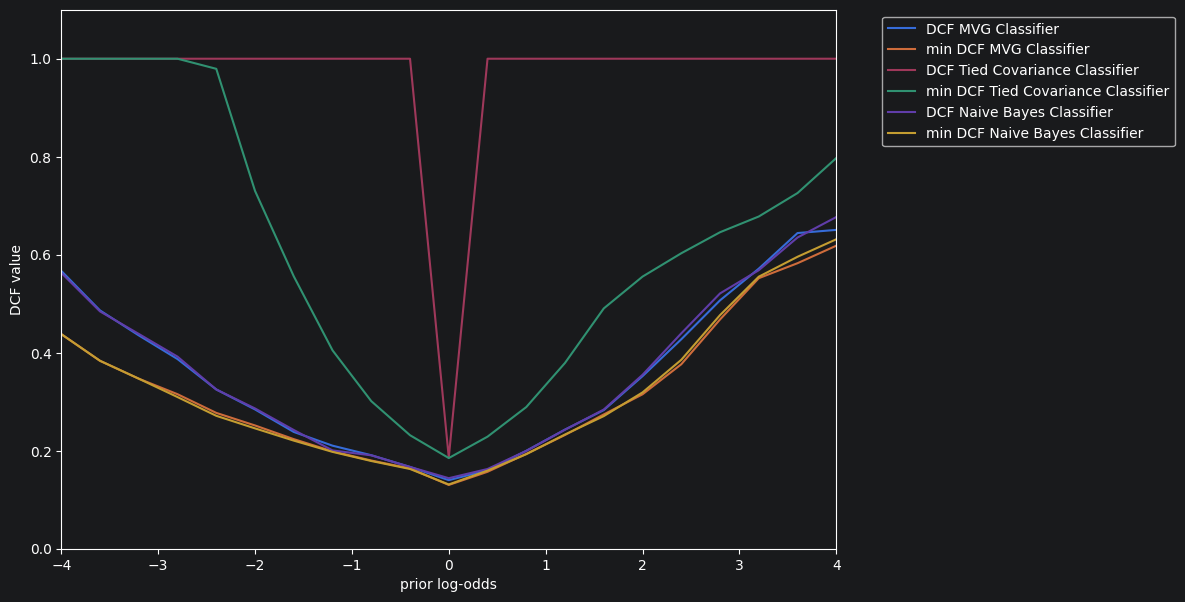

In [12]:
effPriorLogOdds = np.linspace(-4, 4, 21)

dcf_0=[]
mindcf_0=[]
dcf_1=[]
mindcf_1=[]
dcf_2=[]
mindcf_2=[]

models={
    "MVG Classifier":llr_MVG,
    "Tied Covariance Classifier":llr_TiedC,
    "Naive Bayes Classifier":llr_Naive,
}

for i in effPriorLogOdds:
    for model_name,model_llr in models.items():
        pi=1/(1+np.exp(-i))
        predictions = get_bayes_decision(model_llr, pi, 1, 1)
        resdcf=DCF_norm(predictions,LVAL,pi,1,1)
        resmindcf=compute_min_dcf(model_llr,LVAL,pi,1,1)

        if model_name=="MVG Classifier":
            dcf_0.append(resdcf)
            mindcf_0.append(resmindcf)
        elif model_name=="Tied Covariance Classifier":
            dcf_1.append(resdcf)
            mindcf_1.append(resmindcf)
        elif model_name=="Naive Bayes Classifier":
            dcf_2.append(resdcf)
            mindcf_2.append(resmindcf)
    
plt.figure(figsize=(10, 7))
plt.plot(effPriorLogOdds, dcf_0, label='DCF MVG Classifier')
plt.plot(effPriorLogOdds, mindcf_0, label='min DCF MVG Classifier')
plt.plot(effPriorLogOdds, dcf_1, label='DCF Tied Covariance Classifier')
plt.plot(effPriorLogOdds, mindcf_1, label='min DCF Tied Covariance Classifier')
plt.plot(effPriorLogOdds, dcf_2, label='DCF Naive Bayes Classifier')
plt.plot(effPriorLogOdds, mindcf_2, label='min DCF Naive Bayes Classifier')
plt.ylim([0, 1.1])
plt.xlim([-4, 4])
plt.xlabel("prior log-odds")
plt.ylabel("DCF value")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()